# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [3]:
import pandas as pd

df_raw = pd.read_csv("Чернышенко.csv", header=None)

df_fixed = df_raw[0].str.split(",", expand=True)

df_fixed.to_csv("fixed_data.csv", index=False)

print("Готово. Файл сохранён как fixed_data.csv")

Готово. Файл сохранён как fixed_data.csv


In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv("fixed_data.csv", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
1,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
2,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
3,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
4,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y


In [8]:
columns = ['party'] + [f'feature_{i}' for i in range(1, data.shape[1])]
data.columns = columns
data.head()

,party,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16
0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
1,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
2,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
3,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
4,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y


In [9]:
data = data.replace({'y': 1, 'n': 0, '?': 2})

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['party'] = label_encoder.fit_transform(data['party'])

data.head()

,party,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16
0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
1,2,0,1,0,1,1,1,0,0,0,1,2,1,1,1,0,1
2,2,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0,2
3,1,2,1,1,2,1,1,0,0,0,0,1,0,1,1,0,0
4,1,0,1,1,0,2,1,0,0,0,0,1,0,1,0,0,1


In [10]:
X = data.drop('party', axis=1).values
y = data['party'].values

print(X.shape)
print(y.shape)

(436, 16)
(436,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = models.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    batch_size=16
)

ValueError: Invalid dtype: object

In [16]:
print(data.head())
print(data.dtypes)

   party feature_1 feature_2 feature_3 feature_4 feature_5 feature_6  \
0      0         1         2         3         4         5         6   
1      2         0         1         0         1         1         1   
2      2         0         1         0         1         1         1   
3      1         2         1         1         2         1         1   
4      1         0         1         1         0         2         1   

  feature_7 feature_8 feature_9 feature_10 feature_11 feature_12 feature_13  \
0         7         8         9         10         11         12         13   
1         0         0         0          1          2          1          1   
2         0         0         0          0          0          1          1   
3         0         0         0          0          1          0          1   
4         0         0         0          0          1          0          1   

  feature_14 feature_15 feature_16  
0         14         15         16  
1          1      

In [19]:
data = pd.read_csv("fixed_data.csv", header=None)

columns = ['party'] + [f'feature_{i}' for i in range(1, data.shape[1])]
data.columns = columns

data = data.replace({'y': 1, 'n': 0, '?': 2})

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['party'] = label_encoder.fit_transform(data['party'])

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()

print(data.head())
print(data.dtypes)
print(data.shape)

   party  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      0          1          2          3          4          5          6   
1      2          0          1          0          1          1          1   
2      2          0          1          0          1          1          1   
3      1          2          1          1          2          1          1   
4      1          0          1          1          0          2          1   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0          7          8          9          10          11          12   
1          0          0          0           1           2           1   
2          0          0          0           0           0           1   
3          0          0          0           0           1           0   
4          0          0          0           0           1           0   

   feature_13  feature_14  feature_15  feature_16  
0          13          14         

In [25]:
X = data.drop('party', axis=1).values.astype('float32')
y = data['party'].values.astype('float32')

print(X.dtype)
print(y.dtype)
print(X.shape, y.shape)

float32
float32
(436, 16) (436,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    batch_size=16
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5144 - loss: 0.6647 - val_accuracy: 0.5455 - val_loss: 0.6040
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6293 - loss: 0.5635 - val_accuracy: 0.5455 - val_loss: 0.4839
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6293 - loss: 0.4247 - val_accuracy: 0.5455 - val_loss: 0.3039
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6293 - loss: 0.2279 - val_accuracy: 0.5455 - val_loss: 0.0730
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6293 - loss: 0.0228 - val_accuracy: 0.5455 - val_loss: -0.1364
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6293 - loss: -0.1473 - val_accuracy: 0.5455 - val_loss: -0.3040
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6293 - loss: -0.2915 - val_accuracy: 0.5455 - val_loss: -0.4597
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6293 - loss: -0.4285 - val_accuracy: 0.5455 - va

In [23]:
data = data.replace({'y': 1, 'n': 0, '?': np.nan})
data = data.fillna(0)

In [24]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [29]:
print("Уникальные значения y:", np.unique(y))
print("Тип X:", X.dtype)
print("Тип y:", y.dtype)
print("Первые 10 y:", y[:10])
print("Есть ли NaN в X:", np.isnan(X).sum())
print("Есть ли NaN в y:", np.isnan(y).sum())

Уникальные значения y: [0. 1. 2.]
Тип X: float32
Тип y: float32
Первые 10 y: [0. 2. 2. 1. 1. 1. 1. 1. 2. 2.]
Есть ли NaN в X: 0
Есть ли NaN в y: 0


In [30]:
print(data.head(10))
print(data.dtypes)

   party  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      0          1          2          3          4          5          6   
1      2          0          1          0          1          1          1   
2      2          0          1          0          1          1          1   
3      1          2          1          1          2          1          1   
4      1          0          1          1          0          2          1   
5      1          1          1          1          0          1          1   
6      1          0          1          1          0          1          1   
7      1          0          1          0          1          1          1   
8      2          0          1          0          1          1          1   
9      2          0          1          0          1          1          1   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0          7          8          9          10          11         

In [31]:
data = pd.read_csv("fixed_data.csv")

In [32]:
columns = ['party'] + [f'feature_{i}' for i in range(1, data.shape[1])]
data.columns = columns

data = data.replace({'y': 1, 'n': 0, '?': np.nan})

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['party'] = label_encoder.fit_transform(data['party'])

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.fillna(0)

X = data.drop('party', axis=1).values.astype('float32')
y = data['party'].values.astype('float32')

print("Уникальные значения y:", np.unique(y))
print(data.head())

Уникальные значения y: [0. 1.]
   party  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      1        0.0        1.0        0.0        1.0        1.0        1.0   
1      1        0.0        1.0        0.0        1.0        1.0        1.0   
2      0        0.0        1.0        1.0        0.0        1.0        1.0   
3      0        0.0        1.0        1.0        0.0        0.0        1.0   
4      0        1.0        1.0        1.0        0.0        1.0        1.0   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0        0.0        0.0        0.0         1.0         0.0         1.0   
1        0.0        0.0        0.0         0.0         0.0         1.0   
2        0.0        0.0        0.0         0.0         1.0         0.0   
3        0.0        0.0        0.0         0.0         1.0         0.0   
4        0.0        0.0        0.0         0.0         1.0         0.0   

   feature_13  feature_14  feature_15  feature_16  
0  

In [33]:
print("Уникальные значения y:", np.unique(y))

Уникальные значения y: [0. 1.]


In [34]:
data = pd.read_csv("fixed_data.csv")
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y


In [35]:
columns = ['party'] + [f'feature_{i}' for i in range(1, data.shape[1])]
data.columns = columns
data.head()

,party,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y


In [36]:
data = data.replace({'y': 1, 'n': 0, '?': np.nan})

In [37]:
label_encoder = LabelEncoder()
data['party'] = label_encoder.fit_transform(data['party'])

In [38]:
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [39]:
data = data.fillna(0)

In [40]:
print(data.head())
print(data.dtypes)
print("Уникальные значения party:", data['party'].unique())

   party  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      1        0.0        1.0        0.0        1.0        1.0        1.0   
1      1        0.0        1.0        0.0        1.0        1.0        1.0   
2      0        0.0        1.0        1.0        0.0        1.0        1.0   
3      0        0.0        1.0        1.0        0.0        0.0        1.0   
4      0        1.0        1.0        1.0        0.0        1.0        1.0   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0        0.0        0.0        0.0         1.0         0.0         1.0   
1        0.0        0.0        0.0         0.0         0.0         1.0   
2        0.0        0.0        0.0         0.0         1.0         0.0   
3        0.0        0.0        0.0         0.0         1.0         0.0   
4        0.0        0.0        0.0         0.0         1.0         0.0   

   feature_13  feature_14  feature_15  feature_16  
0         1.0         1.0         

In [41]:
X = data.drop('party', axis=1).values.astype('float32')
y = data['party'].values.astype('float32')

print("Уникальные значения y:", np.unique(y))
print("Тип X:", X.dtype)
print("Тип y:", y.dtype)
print("Есть ли NaN в X:", np.isnan(X).sum())
print("Есть ли NaN в y:", np.isnan(y).sum())

Уникальные значения y: [0. 1.]
Тип X: float32
Тип y: float32
Есть ли NaN в X: 0
Есть ли NaN в y: 0


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (348, 16)
Размер X_test: (87, 16)
Размер y_train: (348,)
Размер y_test: (87,)


In [43]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8649 - loss: 0.5253 - val_accuracy: 0.8966 - val_loss: 0.4452
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8879 - loss: 0.4026 - val_accuracy: 0.9080 - val_loss: 0.3406
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9052 - loss: 0.3129 - val_accuracy: 0.9425 - val_loss: 0.2661
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9138 - loss: 0.2505 - val_accuracy: 0.9425 - val_loss: 0.2153
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9224 - loss: 0.2031 - val_accuracy: 0.9425 - val_loss: 0.1812
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9282 - loss: 0.1746 - val_accuracy: 0.9425 - val_loss: 0.1608
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9368 - loss: 0.1523 - val_accuracy: 0.9425 - val_loss: 0.1448
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9511 - loss: 0.1308 - val_accuracy: 0.9425 - val_loss:

In [46]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9655 - loss: 0.1072
Loss: 0.10717222094535828
Accuracy: 0.9655172228813171


In [47]:
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int)

print("Предсказанные классы:")
print(predicted_classes[:10])

print("Правильные ответы:")
print(y_test[:10])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Предсказанные классы:
[[0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]]
Правильные ответы:
[0. 0. 1. 1. 1. 1. 0. 1. 0. 1.]


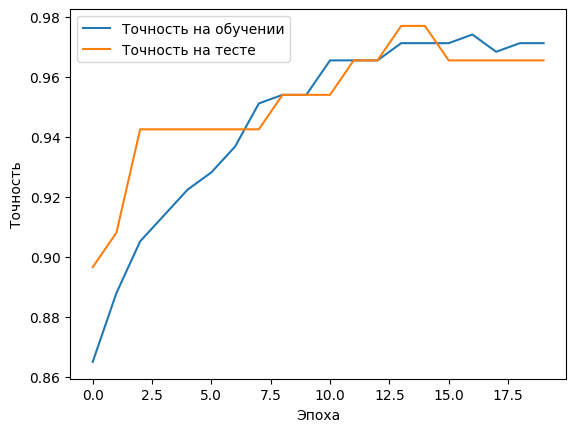

In [48]:
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.show()

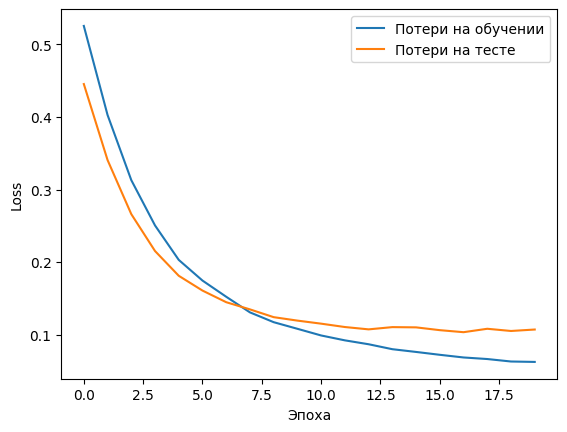

In [49]:
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.show()

используется классификация